# TP Module 4 — Déploiement : TorchScript, ONNX & Quantification (DermaMNIST)

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

1. Comprendre pourquoi un `state_dict` **ne suffit pas** en production, et ce qu'apporte un **artefact autonome** : graphe figé, exécutable sans Python, optimisable et versionnable
2. Sérialiser un modèle en **TorchScript** avec `torch.jit.trace` et `torch.jit.script`, distinguer les deux et démasquer le **piège du contrôle de flux**
3. Exporter au format **ONNX** (`torch.onnx.export`, `opset_version`, `dynamic_axes`) et exécuter l'inférence avec **ONNX Runtime** (batch variable)
4. **Valider numériquement** chaque export — *règle d'or* : mêmes entrées $\Rightarrow$ sorties identiques à $10^{-5}$ près entre le modèle Python et l'artefact
5. Formaliser et implémenter **from scratch** la **quantification affine** $\mathrm{int8}$ (échelle $s$, zéro-point $z$, formules $q$ et $\hat x$), en retrouvant l'exemple chiffré du cours
6. Appliquer les API PyTorch — quantification **dynamique** et **statique (PTQ)** sur le **ResNet18 du TP 04** — et mesurer les gains réels (taille $\div 4$, latence, précision)
7. Assembler un **pipeline de production de bout en bout** (prétraitement $\to$ inférence) et exporter les artefacts validés

## Pré-requis

- Modules 1 à 4 — en particulier le **TP 04** (transfer learning), dont on **réutilise le checkpoint** `resnet18_dermamnist_best.pt`
- `torch`, `torchvision`, `medmnist`, `numpy`, `matplotlib`, `scikit-learn`
- **Optionnel** (gardé par `HAS_ONNX` / `HAS_ORT`) : `onnx` + `onnxscript` pour l'export, `onnxruntime` pour l'inférence — `pip install onnx onnxscript onnxruntime`
- ⚙️ **Le déploiement se fait sur CPU** : c'est la cible portable par défaut, et la quantification $\mathrm{int8}$ (moteur *qnnpack*) est **CPU-only**. Aucun GPU requis pour ce TP.

## Dataset

On **ne ré-entraîne pas** : le déploiement part d'un modèle **déjà entraîné**. On réutilise le fil rouge **DermaMNIST** 128×128 (dermatoscopie RGB, 7 classes) et le **classifieur ResNet18** sauvegardé au TP 04 (`../module_2/checkpoints/resnet18_dermamnist_best.pt`). Un **repli d'entraînement express** se déclenche si le checkpoint est absent. Téléchargement automatique via `medmnist`.

## Partie I — Rappels théoriques

### I.1 — Pourquoi exporter ? Le checkpoint `.pt` ne suffit pas

Un `state_dict` n'est qu'un **dictionnaire de tenseurs**. Pour le recharger il faut **ré-exécuter la classe Python** du modèle (`class ResNet(nn.Module): ...`) puis `load_state_dict`. La production veut au contraire un **artefact autonome** :

- **sans Python** : exécutable depuis un serveur C++ (`libtorch`), un GPU embarqué, un mobile, un navigateur ;
- **à graphe figé** : la suite d'opérations est gelée, donc **optimisable** (fusion d'opérateurs, précision réduite), **versionnable** et **auditable** ;
- **rapide** : fusion `Conv+BN+ReLU`, quantification $\mathrm{int8}$, runtimes spécialisés.

Deux familles d'export :

| | écosystème | interopérabilité |
|---|---|---|
| **TorchScript** (`torch.jit`) | reste dans PyTorch (`libtorch` C++) | PyTorch Mobile / CoreML |
| **ONNX** (`torch.onnx.export`) | **format ouvert** | ONNX Runtime, TensorRT, OpenVINO, navigateur |

> **Règle d'or.** *Toujours valider numériquement l'export* : pour les mêmes entrées, l'artefact et le modèle Python doivent produire des sorties identiques à $10^{-5}$ près. Un export silencieusement faux est pire qu'une erreur franche.

### I.2 — TorchScript : `trace` vs `script`

|  | `torch.jit.trace` | `torch.jit.script` |
|---|---|---|
| **Principe** | **exécute** le modèle sur un exemple et **enregistre** les opérations vues | **compile** le code source (sous-ensemble de Python) |
| **Contrôle de flux** (`if`/`for` dépendant des données) | **figé** sur l'exemple | **préservé** |
| **Limites** | branches conditionnelles perdues | sous-ensemble de Python seulement |

**Piège classique.** Un `if x.mean() > 0:` dans le `forward` est **silencieusement figé** par `trace` : seule la branche prise à l'export survit. Si une autre entrée devait emprunter l'autre branche, le résultat est **faux sans avertissement**. Remède : utiliser `script`, *ou* tracer avec des entrées couvrant **toutes** les branches, *ou* — toujours — **valider numériquement**.

$$
\text{trace} \;:\; f_{\text{trace}}(x) \;=\; \text{graphe}\big(f, x_{\text{exemple}}\big)(x)
\qquad\text{vs}\qquad
\text{script}\;:\; f_{\text{script}} \;=\; \text{compile}(f).
$$

### I.3 — ONNX : le format d'échange interopérable

```python
torch.onnx.export(
    model, x, "model.onnx",
    opset_version=17,                       # jeu d'opérateurs ONNX (fixe la compatibilité runtime)
    input_names=["image"], output_names=["logits"],
    dynamic_axes={"image": {0: "batch"},    # batch variable à l'inférence
                  "logits": {0: "batch"}})
```

- **`opset_version`** : version du jeu d'opérateurs ONNX ; fige la compatibilité avec le runtime cible.
- **`dynamic_axes`** : déclare les dimensions variables (typiquement le *batch*) ; sinon la taille de l'exemple est **figée**.
- L'export **trace** le modèle $\Rightarrow$ mêmes précautions de contrôle de flux que `jit.trace`.

Un **seul artefact**, plusieurs cibles : **ONNX Runtime** (CPU/GPU, serveur & edge), **TensorRT** (GPU NVIDIA, fusion + FP16/INT8), **OpenVINO** (CPU Intel), **CoreML** (Apple).

> Depuis **PyTorch 2.9**, l'exporteur par défaut est le nouveau moteur **`torch.export`** (`dynamo=True`). On utilise ici `dynamo=False` (exporteur historique TorchScript) pour coller exactement à la signature `input_names / output_names / dynamic_axes` du cours et obtenir un *opset* déterministe ; le code `dynamo=True` est indiqué en commentaire.

### I.4 — Quantification : $\mathrm{float32} \to \mathrm{int8}$

**Principe.** Remplacer les flottants 32 bits par des entiers 8 bits via une transformation **affine** (par tenseur ou par canal). Pour un intervalle $[x_{\min}, x_{\max}]$ et une cible non signée $[0, 255]$ :

$$
q \;=\; \operatorname{clamp}\!\Big(\Big\lfloor \tfrac{x}{s} \Big\rceil + z,\; 0,\; 255\Big),
\qquad
\hat x \;=\; s\,(q - z),
\qquad
s \;=\; \frac{x_{\max}-x_{\min}}{255},
\qquad
z \;=\; -\Big\lfloor \tfrac{x_{\min}}{s} \Big\rceil .
$$

$s$ est l'**échelle** (*scale*), $z$ le **zéro-point** (l'entier qui code exactement $x=0$), et $\lfloor\cdot\rceil$ l'arrondi au plus proche.

**Exemple chiffré (cours).** Des activations dans $[-1, 1]$ donnent
$$
s = \frac{2}{255} \approx 0{,}0078, \qquad z = -\Big\lfloor \tfrac{-1}{s} \Big\rceil = 128,
$$
et l'**erreur de quantification maximale** vaut $s/2 \approx 0{,}004$ — négligeable pour la plupart des classifieurs.

**Trois stratégies.**

| Stratégie | Idée | Cas idéal |
|---|---|---|
| **Dynamique** | poids $\mathrm{int8}$, activations quantifiées *à la volée* — 1 ligne | `Linear` / `LSTM` |
| **Statique (PTQ)** | calibration sur quelques *batches* $\to$ échelles d'activation **figées** | CNN |
| **QAT** | *fausse* quantification pendant le fine-tuning | meilleure précision finale |

**Gains typiques (CPU).** Taille $\approx \times \tfrac14$ ; latence $\times 2$ à $\times 4$ plus rapide ; précision $-0$ à $-1$ point (PTQ).

## Partie II — Mise en place : environnement, données, modèle à déployer

On prépare le terrain du déploiement, **sans rien ré-entraîner** :

- **cible CPU** — `DEPLOY_DEVICE = cpu` et moteur quantifié `qnnpack` : c'est la cible portable par défaut, et la quantification $\mathrm{int8}$ y est **CPU-only** ;
- **dépendances optionnelles** gardées par des drapeaux `HAS_ONNX` / `HAS_ORT` : le notebook tourne même sans `onnx` / `onnxruntime` ;
- **modèle à déployer** : le **ResNet18 fine-tuné au TP 04**, rechargé depuis son checkpoint (repli : entraînement express si le fichier est absent) ;
- deux petits sous-ensembles — un pour la **calibration** de la PTQ (Partie VI), un pour l'**évaluation** — car tout tourne sur CPU.

In [1]:
import os, time, copy, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import models
from torchvision.transforms import v2 as T
from medmnist import DermaMNIST, INFO

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# --- Le déploiement cible le CPU : artefact portable + quantification int8 (qnnpack) CPU-only.
DEPLOY_DEVICE = torch.device("cpu")
torch.backends.quantized.engine = "qnnpack"     # backend int8 d'Apple/ARM (et build conda)

# --- Dépendances de déploiement, gardées par des flags (le notebook tourne même sans elles).
try:
    import onnx                                  # nécessaire à l'export (opset, sérialisation)
    HAS_ONNX = True
except Exception:
    HAS_ONNX = False
try:
    import onnxruntime as ort                    # nécessaire à l'inférence ONNX
    HAS_ORT = True
except Exception:
    HAS_ORT = False

print(f"PyTorch : {torch.__version__}  |  torchvision : {models.__name__.split('.')[0]} {__import__('torchvision').__version__}")
print(f"Cible déploiement : {DEPLOY_DEVICE}  |  moteur quantifié : {torch.backends.quantized.engine}")
print(f"onnx : {'OK ' + onnx.__version__ if HAS_ONNX else 'absent'}  |  onnxruntime : {'OK ' + ort.__version__ if HAS_ORT else 'absent'}")

PyTorch : 2.10.0  |  torchvision : torchvision 0.25.0
Cible déploiement : cpu  |  moteur quantifié : qnnpack
onnx : OK 1.21.0  |  onnxruntime : OK 1.24.3


In [2]:
# --- Données : on retrouve le cache 128×128 du Module 1 (sinon dossier local).
DATA_DIR = Path("../module_1/data")
if not DATA_DIR.exists():
    DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True, parents=True)
CKPT_DIR = Path("./checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
EXPORT_DIR = Path("./checkpoints"); EXPORT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 128
BATCH    = 64
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

info          = INFO["dermamnist"]
NUM_CLASSES   = len(info["label"])                                  # 7
CLASSES       = [info["label"][str(i)] for i in range(NUM_CLASSES)]
CLASSES_SHORT = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

def make_derma(split, transform=None, target_transform=None):
    """Charge un split DermaMNIST en size=IMG_SIZE (RGB natif), repli 28×28 si medmnist < 3.0."""
    kwargs = dict(split=split, root=DATA_DIR, download=True,
                  transform=transform, target_transform=target_transform)
    try:
        return DermaMNIST(size=IMG_SIZE, **kwargs)
    except TypeError:
        return DermaMNIST(**kwargs)

squeeze_target = lambda t: int(np.asarray(t).reshape(-1)[0])

# Prétraitement d'inférence (déterministe) — identique à l'`eval` du TP 04.
eval_tf = T.Compose([
    T.Resize(int(IMG_SIZE * 1.14), antialias=True),
    T.CenterCrop(IMG_SIZE),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_set = make_derma("test", transform=eval_tf, target_transform=squeeze_target)
val_set  = make_derma("val",  transform=eval_tf, target_transform=squeeze_target)
print(f"Test : {len(test_set)} images  |  Val : {len(val_set)} images  |  {NUM_CLASSES} classes {CLASSES_SHORT}")

# Sous-ensembles légers : calibration (PTQ) et évaluation (CPU -> on reste raisonnable).
g = torch.Generator().manual_seed(SEED)
calib_idx = torch.randperm(len(val_set),  generator=g)[:256].tolist()
eval_idx  = torch.randperm(len(test_set), generator=g)[:512].tolist()
calib_loader = DataLoader(Subset(val_set,  calib_idx), batch_size=BATCH, shuffle=False)
eval_loader  = DataLoader(Subset(test_set, eval_idx),  batch_size=BATCH, shuffle=False)
print(f"Calibration : {len(calib_idx)} images  |  Évaluation : {len(eval_idx)} images")

Test : 2005 images  |  Val : 1003 images  |  7 classes ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Calibration : 256 images  |  Évaluation : 512 images


In [3]:
# --- Modèle à déployer : le ResNet18/DermaMNIST du TP 04 (repli : entraînement express).
def build_resnet18(num_classes=NUM_CLASSES):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

CKPT_TP04 = Path("../module_2/checkpoints/resnet18_dermamnist_best.pt")
model = build_resnet18().to(DEPLOY_DEVICE)

if CKPT_TP04.exists():
    state = torch.load(CKPT_TP04, map_location=DEPLOY_DEVICE, weights_only=False)
    model.load_state_dict(state["model_state_dict"])
    IMG_SIZE       = state.get("img_size", IMG_SIZE)
    IMAGENET_MEAN  = tuple(state.get("normalize_mean", IMAGENET_MEAN))
    IMAGENET_STD   = tuple(state.get("normalize_std",  IMAGENET_STD))
    print(f"Checkpoint TP 04 chargé ({CKPT_TP04.name}) — test_acc rapportée : {state.get('test_acc', float('nan')):.3f}")
else:
    # Repli : quelques centaines de pas pour disposer d'un modèle non trivial à déployer.
    print("Checkpoint TP 04 absent -> entraînement express de repli (modèle de démonstration).")
    train_set = make_derma("train", transform=eval_tf, target_transform=squeeze_target)
    tl = DataLoader(Subset(train_set, list(range(2048))), batch_size=BATCH, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for ep in range(2):
        for xb, yb in tl:
            opt.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward(); opt.step()
        print(f"  epoch {ep+1} | loss {loss.item():.3f}")

model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f"ResNet18 prêt : {n_params/1e6:.2f} M paramètres, entrée {IMG_SIZE}×{IMG_SIZE}, sortie {NUM_CLASSES} logits.")

Checkpoint TP 04 chargé (resnet18_dermamnist_best.pt) — test_acc rapportée : 0.675
ResNet18 prêt : 11.18 M paramètres, entrée 128×128, sortie 7 logits.


In [4]:
# --- Outils communs : taille disque, latence, exactitude / macro-F1.
from sklearn.metrics import f1_score

def file_size_mb(path):
    return os.path.getsize(path) / 1e6

def state_size_mb(model, tmp="./checkpoints/_tmp_size.pt"):
    torch.save(model.state_dict(), tmp)
    mb = file_size_mb(tmp); os.remove(tmp); return mb

@torch.no_grad()
def bench_latency(fn, x, n=50, warmup=10):
    """Latence moyenne (ms) d'une fonction d'inférence sur une entrée fixe."""
    for _ in range(warmup): fn(x)
    t0 = time.perf_counter()
    for _ in range(n): fn(x)
    return (time.perf_counter() - t0) / n * 1e3

@torch.no_grad()
def evaluate_torch(model, loader):
    model.eval(); ys, ps = [], []
    for xb, yb in loader:
        logits = model(xb)
        ps.append(logits.argmax(1).cpu()); ys.append(yb)
    y = torch.cat(ys).numpy(); p = torch.cat(ps).numpy()
    return (p == y).mean(), f1_score(y, p, average="macro")

# Une image de référence et un batch, pour les exports et les benchmarks.
x1, _ = test_set[eval_idx[0]]
x1 = x1.unsqueeze(0).to(DEPLOY_DEVICE).contiguous()      # (1,3,H,W) ; .contiguous() pour MPS-safety
print("Entrée de référence :", tuple(x1.shape))

acc0, f10 = evaluate_torch(model, eval_loader)
ref_logits = model(x1)
print(f"Référence float32 (eager) — accuracy {acc0:.3f} | macro-F1 {f10:.3f}")

Entrée de référence : (1, 3, 128, 128)


Référence float32 (eager) — accuracy 0.689 | macro-F1 0.504


## Partie III — TorchScript : `trace`, `script` et le piège du contrôle de flux

On sérialise le ResNet18 par les deux voies, on **valide numériquement** (`torch.allclose`, $10^{-5}$), puis on construit un mini-modèle à branche conditionnelle pour **voir** `trace` figer une branche — et `script` la préserver.

In [5]:
# (1) TRACE : exécute le modèle sur une entrée et enregistre les ops.
traced = torch.jit.trace(model, x1)
traced.save(str(EXPORT_DIR / "resnet18_dermamnist.torchscript.pt"))

# (2) SCRIPT : compile le code source (sous-ensemble de Python).
scripted = torch.jit.script(model)

# (3) Re-chargement d'un artefact (aucune classe Python requise pour le load).
reloaded = torch.jit.load(str(EXPORT_DIR / "resnet18_dermamnist.torchscript.pt"))

# (4) Validation numérique — la règle d'or.
ok_trace  = torch.allclose(ref_logits, traced(x1),   atol=1e-5)
ok_script = torch.allclose(ref_logits, scripted(x1), atol=1e-5)
ok_reload = torch.allclose(ref_logits, reloaded(x1), atol=1e-5)
print(f"allclose(model, traced)   = {ok_trace}")
print(f"allclose(model, scripted) = {ok_script}")
print(f"allclose(model, reloaded) = {ok_reload}   (artefact relu depuis le disque)")
print(f"Taille artefact TorchScript : {file_size_mb(EXPORT_DIR / 'resnet18_dermamnist.torchscript.pt'):.2f} MB")
assert ok_trace and ok_script and ok_reload, "Export TorchScript non conforme !"

allclose(model, traced)   = True
allclose(model, scripted) = True
allclose(model, reloaded) = True   (artefact relu depuis le disque)
Taille artefact TorchScript : 44.93 MB


In [6]:
# --- Le piège : une branche conditionnelle dépendante des données.
class SignedScaler(nn.Module):
    def forward(self, x):
        if x.mean() > 0:        # <-- contrôle de flux dépendant de l'entrée
            return x * 2.0
        else:
            return x * -1.0

f = SignedScaler().eval()
x_pos = torch.ones(4)          # exemple de trace : moyenne > 0  -> branche x*2
x_neg = -torch.ones(4)         # entrée de test : moyenne < 0    -> devrait être x*-1 = +1

f_traced = torch.jit.trace(f, x_pos)      # tracé sur l'exemple POSITIF
f_scripted = torch.jit.script(f)

print("Entrée négative x = [-1,-1,-1,-1] ; sortie attendue = [1,1,1,1]")
print("  eager  :", f(x_neg).tolist())
print("  trace  :", f_traced(x_neg).tolist(), " <- branche x*2 FIGÉE -> FAUX, sans avertissement")
print("  script :", f_scripted(x_neg).tolist(), " <- branche correcte préservée")
print()
print("Leçon : pour du contrôle de flux dépendant des données, utiliser jit.script,")
print("        ou tracer avec des entrées couvrant TOUTES les branches — et toujours valider.")

Entrée négative x = [-1,-1,-1,-1] ; sortie attendue = [1,1,1,1]
  eager  : [1.0, 1.0, 1.0, 1.0]
  trace  : [-2.0, -2.0, -2.0, -2.0]  <- branche x*2 FIGÉE -> FAUX, sans avertissement
  script : [1.0, 1.0, 1.0, 1.0]  <- branche correcte préservée

Leçon : pour du contrôle de flux dépendant des données, utiliser jit.script,
        ou tracer avec des entrées couvrant TOUTES les branches — et toujours valider.


/var/folders/q2/01kjvnw958g_b78gjjzklwy40000gp/T/ipykernel_3053/2911760779.py:4: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.mean() > 0:        # <-- contrôle de flux dépendant de l'entrée


**À retenir.** `trace` ne voit que **les opérations exécutées** sur l'exemple : un `if`/`for` dépendant des données est gelé. `script` lit le **code source** et préserve la logique. Pour un CNN purement *feed-forward* comme ResNet18, `trace` suffit (et donne souvent un graphe plus simple) ; dès qu'il y a une branche conditionnelle, préférer `script`. L'artefact `.pt` se recharge ensuite **en C++** (`torch::jit::load`) — aucun interpréteur Python en production.

## Partie IV — ONNX : export interopérable & inférence ONNX Runtime

Export `opset 17` avec entrées/sorties nommées et **batch dynamique**, puis inférence **ONNX Runtime** sur CPU, validation numérique contre PyTorch, et démonstration du *batch* variable que `dynamic_axes` autorise.

In [7]:
ONNX_PATH = EXPORT_DIR / "resnet18_dermamnist.onnx"

if HAS_ONNX:
    torch.onnx.export(
        model, x1, str(ONNX_PATH),
        opset_version=17,
        input_names=["image"], output_names=["logits"],
        dynamic_axes={"image": {0: "batch"}, "logits": {0: "batch"}},
        dynamo=False,                       # exporteur historique = signature/опset du cours
    )
    # Variante moderne (PyTorch >= 2.9), pour information :
    # torch.onnx.export(model, x1, "model.onnx", dynamo=True,
    #                   input_names=["image"], output_names=["logits"])
    onnx_model = onnx.load(str(ONNX_PATH))
    onnx.checker.check_model(onnx_model)    # validation structurelle du graphe
    print(f"Export ONNX OK : {ONNX_PATH.name} ({file_size_mb(ONNX_PATH):.2f} MB), opset {onnx_model.opset_import[0].version}")
    print("Entrées :", [i.name for i in onnx_model.graph.input],
          "| Sorties :", [o.name for o in onnx_model.graph.output])
else:
    print("`onnx` absent -> export sauté. Installez : pip install onnx onnxscript")

Export ONNX OK : resnet18_dermamnist.onnx (44.71 MB), opset 17
Entrées : ['image'] | Sorties : ['logits']


In [8]:
if HAS_ORT and ONNX_PATH.exists():
    sess = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
    inp = sess.get_inputs()[0].name

    # (a) Validation numérique contre PyTorch (règle d'or).
    out_ort = sess.run(None, {inp: x1.numpy()})[0]
    ok = np.allclose(out_ort, ref_logits.detach().numpy(), atol=1e-4)
    print(f"allclose(PyTorch, ONNX Runtime) = {ok}  | écart max = {np.abs(out_ort - ref_logits.detach().numpy()).max():.2e}")

    # (b) Batch dynamique : la même session accepte une autre taille de batch.
    xb = torch.stack([test_set[i][0] for i in eval_idx[:8]]).numpy()
    out_b = sess.run(None, {inp: xb})[0]
    print(f"Batch dynamique : entrée {xb.shape} -> sortie {out_b.shape}  (dynamic_axes opérationnel)")

    # (c) Latence ONNX Runtime sur une image.
    lat_ort = bench_latency(lambda z: sess.run(None, {inp: z}), x1.numpy())
    print(f"Latence ONNX Runtime (1 image) : {lat_ort:.2f} ms")
else:
    lat_ort = float("nan")
    print("ONNX Runtime indisponible ou pas d'artefact -> inférence ONNX sautée.")

allclose(PyTorch, ONNX Runtime) = True  | écart max = 1.62e-05
Batch dynamique : entrée (8, 3, 128, 128) -> sortie (8, 7)  (dynamic_axes opérationnel)


Latence ONNX Runtime (1 image) : 2.70 ms


## Partie V — Quantification affine *from scratch*

Avant les API PyTorch, on implémente la quantification **à la main** pour ancrer la formule de la Partie I.4 et **retrouver l'exemple chiffré** du cours, puis on l'applique à un vrai tenseur de poids (par tenseur vs **par canal**).

In [9]:
def compute_qparams(x, qmin=0, qmax=255):
    """Échelle s et zéro-point z affines (uint8), formule du cours."""
    xmin = min(float(x.min()), 0.0)            # l'intervalle affine inclut 0
    xmax = max(float(x.max()), 0.0)
    s = (xmax - xmin) / (qmax - qmin)
    z = int(round(qmin - xmin / s))
    z = max(qmin, min(qmax, z))                # zéro-point clampé dans [qmin, qmax]
    return s, z

def quantize(x, s, z, qmin=0, qmax=255):
    return torch.clamp(torch.round(x / s) + z, qmin, qmax).to(torch.uint8)

def dequantize(q, s, z):
    return s * (q.float() - z)

# --- Retrouver l'exemple chiffré du cours : activations dans [-1, 1].
x = torch.linspace(-1, 1, 100_000)
s, z = compute_qparams(x)
xh = dequantize(quantize(x, s, z), s, z)
err_max = (x - xh).abs().max().item()

print(f"Activations dans [-1, 1] :")
print(f"  échelle  s = {s:.6f}   (cours : 2/255 = {2/255:.6f})")
print(f"  zéro-point z = {z}        (cours : 128)")
print(f"  erreur de quantification max mesurée = {err_max:.6f}   (borne théorique s/2 = {s/2:.6f})")
print(f"  -> x = 0 est codé exactement par l'entier q = {int(quantize(torch.zeros(1), s, z).item())} = z, dequant = {dequantize(quantize(torch.zeros(1), s, z), s, z).item():.1e}")

Activations dans [-1, 1] :
  échelle  s = 0.007843   (cours : 2/255 = 0.007843)
  zéro-point z = 128        (cours : 128)
  erreur de quantification max mesurée = 0.003922   (borne théorique s/2 = 0.003922)
  -> x = 0 est codé exactement par l'entier q = 128 = z, dequant = 0.0e+00


Poids conv (64, 64, 3, 3) :
  par tenseur  -> MSE = 2.261e-06   (1 échelle pour tout le tenseur)
  par canal    -> MSE = 6.958e-07   (64 échelles : suit la dynamique de chaque filtre)
  gain par-canal : ×3.2 d'erreur en moins
  compression théorique : 32 bits -> 8 bits = ×4 (poids stockés en int8 + 1 (s,z) par tenseur/canal)


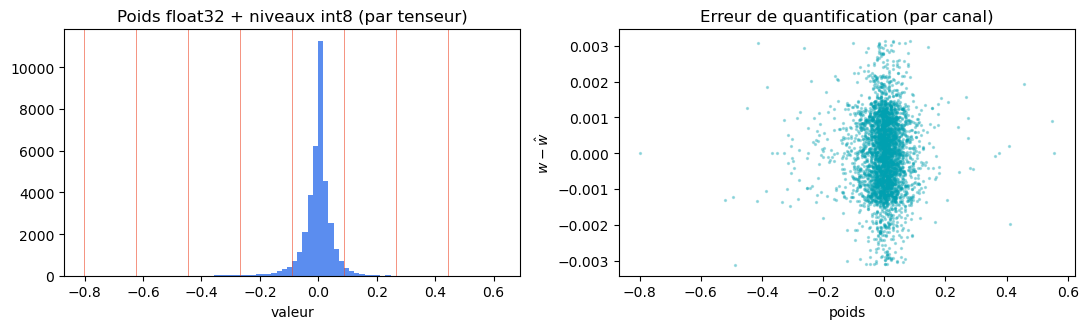

In [10]:
# --- Sur un vrai tenseur de poids : par tenseur (uint8 affine) vs par canal (int8 symétrique).
W = model.layer1[0].conv1.weight.detach().clone()      # (64, 64, 3, 3)

# (a) par tenseur
s_t, z_t = compute_qparams(W)
W_t = dequantize(quantize(W, s_t, z_t), s_t, z_t)
mse_t = F.mse_loss(W, W_t).item()

# (b) par canal de sortie (symétrique signé, comme PyTorch pour les poids de conv)
def quantize_per_channel_symmetric(W, qmax=127):
    Wf = W.reshape(W.shape[0], -1)
    s = Wf.abs().amax(dim=1).clamp(min=1e-12) / qmax            # une échelle par canal
    q = torch.clamp(torch.round(Wf / s[:, None]), -qmax, qmax)
    Wh = (q * s[:, None]).reshape(W.shape)
    return Wh, s
W_c, s_c = quantize_per_channel_symmetric(W)
mse_c = F.mse_loss(W, W_c).item()

print(f"Poids conv {tuple(W.shape)} :")
print(f"  par tenseur  -> MSE = {mse_t:.3e}   (1 échelle pour tout le tenseur)")
print(f"  par canal    -> MSE = {mse_c:.3e}   ({W.shape[0]} échelles : suit la dynamique de chaque filtre)")
print(f"  gain par-canal : ×{mse_t/mse_c:.1f} d'erreur en moins")
print(f"  compression théorique : 32 bits -> 8 bits = ×4 (poids stockés en int8 + 1 (s,z) par tenseur/canal)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(W.flatten().numpy(), bins=80, color="#5B8DEF")
for k in range(0, 256, 32):
    ax[0].axvline(s_t * (k - z_t), color="#EE4C2C", lw=0.6, alpha=0.7)
ax[0].set_title("Poids float32 + niveaux int8 (par tenseur)"); ax[0].set_xlabel("valeur")
ax[1].scatter(W.flatten().numpy()[:4000], (W - W_c).flatten().numpy()[:4000], s=2, alpha=0.3, color="#00A0B0")
ax[1].set_title("Erreur de quantification (par canal)"); ax[1].set_xlabel("poids"); ax[1].set_ylabel(r"$w-\hat w$")
plt.tight_layout(); plt.show()

## Partie VI — Quantification avec PyTorch : dynamique & statique (PTQ)

Place aux API. **Dynamique** : une ligne, mais elle ne touche que `Linear`/`LSTM` — donc presque rien sur un CNN (on le montre sur un `LSTM` où elle brille). **Statique (PTQ)** : la bonne approche pour un CNN — *fusion* `Conv+BN+ReLU`, calibration, puis conversion `int8`, avec mesure des gains réels sur le ResNet18.

In [11]:
# --- (1) Quantification DYNAMIQUE : idéale Linear/LSTM, pas un CNN.
# Sur le ResNet18, seule la tête `fc` est un Linear -> effet négligeable.
dq_resnet = torch.ao.quantization.quantize_dynamic(
    copy.deepcopy(model).cpu(), {nn.Linear}, dtype=torch.qint8)
print(f"ResNet18 — dynamique {{nn.Linear}} : {state_size_mb(model):.1f} MB -> {state_size_mb(dq_resnet):.1f} MB "
      f"(seul `fc` quantifié : le CNN est dominé par les Conv).")

# Là où la quantification dynamique brille : un réseau récurrent.
class RNNHead(nn.Module):
    def __init__(self):
        super().__init__(); self.lstm = nn.LSTM(64, 256, num_layers=2, batch_first=True); self.fc = nn.Linear(256, 10)
    def forward(self, x):
        o, _ = self.lstm(x); return self.fc(o[:, -1])
rnn = RNNHead().eval()
dq_rnn = torch.ao.quantization.quantize_dynamic(rnn, {nn.LSTM, nn.Linear}, dtype=torch.qint8)
print(f"LSTM+Linear — dynamique : {state_size_mb(rnn):.2f} MB -> {state_size_mb(dq_rnn):.2f} MB "
      f"(÷{state_size_mb(rnn)/state_size_mb(dq_rnn):.1f}) — 1 ligne, sans calibration.")

ResNet18 — dynamique {nn.Linear} : 44.8 MB -> 44.8 MB (seul `fc` quantifié : le CNN est dominé par les Conv).
LSTM+Linear — dynamique : 3.44 MB -> 0.89 MB (÷3.8) — 1 ligne, sans calibration.


In [12]:
# --- (2) Quantification STATIQUE (PTQ) du ResNet18 : la voie CNN.
# torchvision fournit une variante "quantifiable" (QuantStub/DeQuantStub + fuse_model),
# qui partage exactement les noms de paramètres : on y recharge nos poids float32.
qmodel = models.quantization.resnet18(weights=None, quantize=False)
qmodel.fc = nn.Linear(qmodel.fc.in_features, NUM_CLASSES)
missing, unexpected = qmodel.load_state_dict(model.state_dict(), strict=False)
assert not missing and not unexpected, (missing, unexpected)
qmodel.eval()

# (a) Fusion Conv+BN+ReLU : moins d'ops, et requis avant la quantification statique.
qmodel.fuse_model(is_qat=False)

# (b) qconfig (observateurs d'activations) pour le backend qnnpack.
qmodel.qconfig = torch.ao.quantization.get_default_qconfig("qnnpack")
torch.ao.quantization.prepare(qmodel, inplace=True)

# (c) Calibration : on fait passer quelques batches pour estimer les plages d'activation.
with torch.no_grad():
    for xb, _ in calib_loader:
        qmodel(xb)

# (d) Conversion en int8.
torch.ao.quantization.convert(qmodel, inplace=True)
print("PTQ terminée : Conv/Linear convertis en int8 (calibration sur "
      f"{len(calib_idx)} images).")

# (e) Gains réels : taille, latence, précision.
size_fp32 = state_size_mb(model)
size_int8 = state_size_mb(qmodel)
lat_fp32  = bench_latency(lambda z: model(z), x1)
lat_int8  = bench_latency(lambda z: qmodel(z), x1)
acc_int8, f1_int8 = evaluate_torch(qmodel, eval_loader)

print(f"\n               float32      int8")
print(f"  taille      {size_fp32:6.1f} MB   {size_int8:6.1f} MB   (÷{size_fp32/size_int8:.1f})")
print(f"  latence/img {lat_fp32:6.1f} ms   {lat_int8:6.1f} ms   (×{lat_fp32/lat_int8:.1f} plus rapide)")
print(f"  accuracy    {acc0:6.3f}      {acc_int8:6.3f}      (Δ {acc_int8-acc0:+.3f})")
print(f"  macro-F1    {f10:6.3f}      {f1_int8:6.3f}      (Δ {f1_int8-f10:+.3f})")

PTQ terminée : Conv/Linear convertis en int8 (calibration sur 256 images).



               float32      int8
  taille        44.8 MB     11.2 MB   (÷4.0)
  latence/img    5.7 ms      3.4 ms   (×1.7 plus rapide)
  accuracy     0.689       0.670      (Δ -0.020)
  macro-F1     0.504       0.511      (Δ +0.007)


**Lecture — les gains promis par le cours.** Le tableau ci-dessus matérialise la ligne « gains typiques (CPU) » du slide quantification : **taille $\approx \div 4$** (les poids passent de 32 à 8 bits), **latence $\times 2$ à $\times 4$** sur CPU (arithmétique entière + backend `qnnpack`), pour une **précision quasi inchangée** ($-0$ à $-1$ point en PTQ). Deux étapes l'ont rendu possible sur un CNN : la **fusion** `Conv+BN+ReLU` (moins d'opérations, *requise* avant la conversion) et la **calibration** (quelques *batches* suffisent à figer les échelles d'activation). Pour minimiser la perte de précision on passerait au **QAT** (exercice 3) ; pour une cible mobile, on combinerait avec `optimize_for_mobile` (cf. synthèse et exercice 6).

## Partie VII — Benchmark de bout en bout : taille & latence

On récapitule visuellement les quatre chemins d'inférence (**eager fp32**, **TorchScript**, **ONNX Runtime**, **int8 PTQ**) sur la même image, côté **latence** et côté **taille d'artefact**.

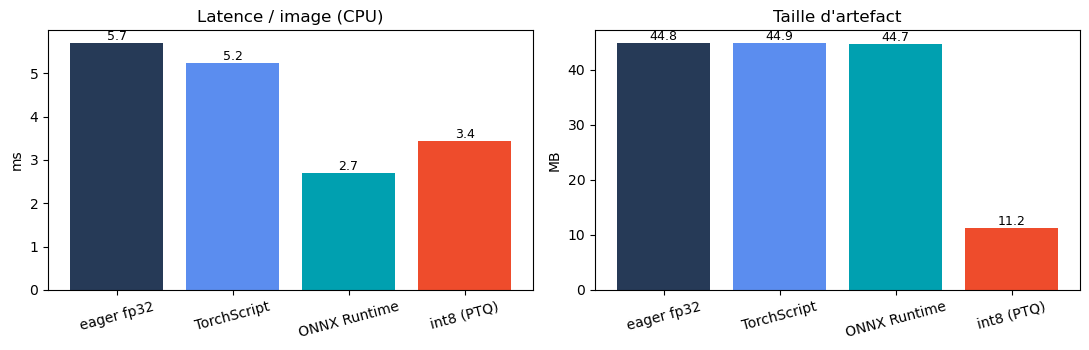

Lecture : int8 ≈ ÷4 en taille (poids 8 bits) ; les latences dépendent du backend CPU
          (qnnpack pour int8, MKL/oneDNN pour fp32, ONNX Runtime pour .onnx).


In [13]:
# Latences (ms) sur une image — toutes sur CPU.
lat_ts = bench_latency(lambda z: traced(z), x1)
variants = ["eager fp32", "TorchScript", "ONNX Runtime", "int8 (PTQ)"]
lats = [lat_fp32, lat_ts, lat_ort, lat_int8]

# Tailles d'artefact (MB).
torch.save(model.state_dict(), EXPORT_DIR / "_fp32_state.pt")
sizes = [
    file_size_mb(EXPORT_DIR / "_fp32_state.pt"),
    file_size_mb(EXPORT_DIR / "resnet18_dermamnist.torchscript.pt"),
    file_size_mb(ONNX_PATH) if ONNX_PATH.exists() else float("nan"),
    state_size_mb(qmodel),
]
os.remove(EXPORT_DIR / "_fp32_state.pt")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
colors = ["#263A57", "#5B8DEF", "#00A0B0", "#EE4C2C"]
ax[0].bar(variants, lats, color=colors)
ax[0].set_title("Latence / image (CPU)"); ax[0].set_ylabel("ms")
for i, v in enumerate(lats):
    ax[0].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
ax[1].bar(variants, sizes, color=colors)
ax[1].set_title("Taille d'artefact"); ax[1].set_ylabel("MB")
for i, v in enumerate(sizes):
    ax[1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
for a in ax: a.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

print("Lecture : int8 ≈ ÷4 en taille (poids 8 bits) ; les latences dépendent du backend CPU")
print("          (qnnpack pour int8, MKL/oneDNN pour fp32, ONNX Runtime pour .onnx).")

## Partie VIII — Pipeline de production de bout en bout

Un classifieur déployé, ce n'est pas seulement un `forward` : c'est **prétraitement $\to$ inférence $\to$ post-traitement**. On encapsule la chaîne complète dans une fonction `predict` autonome qui part d'une **image brute** (tableau `uint8` HWC, comme en sortie de caméra), réutilise l'artefact exporté, et rend la classe + la probabilité.

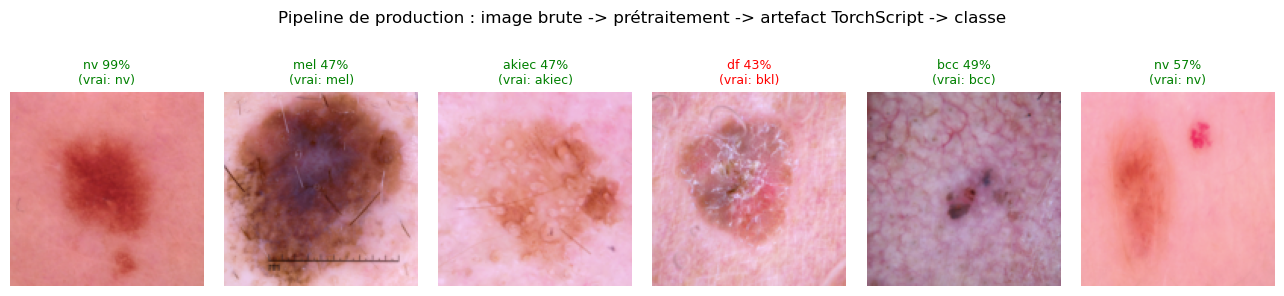

Même image, trois backends :
  eager        -> ('nv', 0.9861706495285034)
  torchscript  -> ('nv', 0.9861706495285034)
  onnx         -> ('nv', 0.9861702919006348)
  int8         -> ('nv', 0.9878824949264526)


In [14]:
from PIL import Image

# Métadonnées embarquées avec l'artefact (échelle de prétraitement, classes).
MEAN = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
STD  = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)

def preprocess(img_uint8):
    """Image brute HWC uint8 -> tenseur (1,3,IMG_SIZE,IMG_SIZE) normalisé."""
    pil = Image.fromarray(img_uint8).convert("RGB")
    t = eval_tf(pil)                                   # resize + crop + scale + normalize
    return t.unsqueeze(0).contiguous()

def predict(img_uint8, backend="torchscript"):
    """Pipeline complet : prétraitement -> inférence (artefact choisi) -> softmax -> top-1."""
    x = preprocess(img_uint8)
    if backend == "torchscript":
        logits = reloaded(x)
    elif backend == "onnx" and HAS_ORT and ONNX_PATH.exists():
        logits = torch.from_numpy(sess.run(None, {sess.get_inputs()[0].name: x.numpy()})[0])
    elif backend == "int8":
        logits = qmodel(x)
    else:
        logits = model(x)
    prob = logits.softmax(1)[0]
    k = int(prob.argmax())
    return CLASSES_SHORT[k], float(prob[k])

# Démonstration sur quelques images brutes du test set (on récupère le uint8 d'origine).
raw_imgs = test_set.imgs[eval_idx[:6]]                 # (N, H, W, 3) uint8
raw_lbls = np.asarray(test_set.labels).reshape(-1)[eval_idx[:6]]

fig, axes = plt.subplots(1, 6, figsize=(13, 2.6))
for ax, im, gt in zip(axes, raw_imgs, raw_lbls):
    name, p = predict(im, backend="torchscript")
    ax.imshow(im); ax.axis("off")
    color = "green" if name == CLASSES_SHORT[gt] else "red"
    ax.set_title(f"{name} {p:.0%}\n(vrai: {CLASSES_SHORT[gt]})", fontsize=9, color=color)
plt.suptitle("Pipeline de production : image brute -> prétraitement -> artefact TorchScript -> classe", y=1.12)
plt.tight_layout(); plt.show()

# Cohérence inter-backends sur la même image.
im0 = raw_imgs[0]
print("Même image, trois backends :")
for b in ["eager", "torchscript", "onnx", "int8"]:
    print(f"  {b:12s} -> {predict(im0, backend=b)}")

In [15]:
# --- Artefacts de déploiement validés, prêts à livrer (convention du dépôt).
print("Artefacts exportés dans ./checkpoints/ :")
for name in ["resnet18_dermamnist.torchscript.pt", "resnet18_dermamnist.onnx"]:
    p = EXPORT_DIR / name
    if p.exists():
        print(f"  {name:42s} {file_size_mb(p):6.2f} MB")

# Le modèle int8 : on tente de le scripter (artefact int8 autonome), sinon on sauve le state_dict.
INT8_PATH = EXPORT_DIR / "resnet18_dermamnist_int8.pt"
try:
    torch.jit.save(torch.jit.script(qmodel), str(INT8_PATH))
    tag = "TorchScript int8"
except Exception:
    torch.save(qmodel.state_dict(), INT8_PATH)
    tag = "state_dict int8"
print(f"  {INT8_PATH.name:42s} {file_size_mb(INT8_PATH):6.2f} MB  ({tag})")
print("\nChaque artefact a été validé numériquement (|f(x) - f̂(x)| < 1e-4 à 1e-5).")

Artefacts exportés dans ./checkpoints/ :
  resnet18_dermamnist.torchscript.pt          44.93 MB
  resnet18_dermamnist.onnx                    44.71 MB
  resnet18_dermamnist_int8.pt                 11.24 MB  (TorchScript int8)

Chaque artefact a été validé numériquement (|f(x) - f̂(x)| < 1e-4 à 1e-5).


## Partie IX — Exercices d'application

1. **Exporter un générateur du TP 10.** Chargez le générateur DCGAN ou SRGAN (`checkpoints/*_dermamnist_best.pt`), tracez-le avec un bruit latent `z ~ N(0, I)` de la bonne forme, sauvegardez en TorchScript et **validez** que `traced(z)` reproduit le `forward` Python à $10^{-5}$. Pourquoi `trace` suffit-il ici ?

2. **PTQ vs quantification dynamique.** Sur le ResNet18, comparez la quantification **dynamique** (`{nn.Linear, nn.Conv2d}` — testez si Conv2d est supporté) et **statique** : taille, latence, accuracy, macro-F1. Faites varier la **taille du set de calibration** (32 / 128 / 512 images) et tracez l'accuracy en fonction.

3. **QAT (Quantization-Aware Training).** Reprenez la variante quantifiable, appelez `prepare_qat` au lieu de `prepare`, *fine-tunez* 1–2 époques avec la *fausse* quantification active, puis `convert`. La précision finale dépasse-t-elle celle de la PTQ ?

4. **`dynamic_axes` avancé.** Ré-exportez en ONNX avec *batch* **et** dimensions spatiales dynamiques (`{2: "h", 3: "w"}`). Vérifiez sous ONNX Runtime l'inférence à 96×96 et 160×160. Que se passe-t-il pour les couches qui supposent une taille fixe ?

5. **Erreur par canal vs par tenseur.** Pour chaque couche conv du ResNet18, calculez la MSE de reconstruction *par tenseur* et *par canal* (réutilisez `quantize_per_channel_symmetric`). Tracez l'histogramme des gains : quelles couches profitent le plus du par-canal ?

6. **PyTorch Mobile.** Appliquez `torch.utils.mobile_optimizer.optimize_for_mobile(scripted)` puis `_save_for_lite_interpreter("model.ptl")`. Comparez la taille et inspectez les fusions opérées. Combinez avec la quantification.

7. **Chasse au piège de `trace`.** Construisez un classifieur dont le `forward` contient une branche `if` (ex. *test-time augmentation* conditionnelle). Montrez que `trace` la fige, qu'une validation sur une entrée empruntant l'autre branche **échoue**, et corrigez avec `script`.

## Synthèse — concepts ↔ formules ↔ API PyTorch

| Concept | Idée clé / formule | PyTorch / outil |
|---|---|---|
| **TorchScript — trace** | exécute & enregistre les ops ; contrôle de flux **figé** | `torch.jit.trace`, `.save` / `torch.jit.load` |
| **TorchScript — script** | compile le code source ; contrôle de flux **préservé** | `torch.jit.script` |
| **Export ONNX** | graphe figé, *opset* + `dynamic_axes` | `torch.onnx.export(opset_version, input_names, dynamic_axes)` |
| **Inférence ONNX** | runtime multi-cibles (CPU/GPU/edge) | `onnxruntime.InferenceSession(...).run` |
| **Validation (règle d'or)** | $\lvert f(x) - \hat f(x)\rvert < 10^{-5}$ | `torch.allclose`, `np.allclose` |
| **Quantification affine** | $q=\operatorname{clamp}(\lfloor x/s\rceil + z),\ \hat x = s(q-z),\ s=\tfrac{x_{\max}-x_{\min}}{255}$ | quantif. *from scratch* (uint8 / per-canal) |
| **Quant. dynamique** | poids $\mathrm{int8}$, activations à la volée | `torch.ao.quantization.quantize_dynamic` |
| **Quant. statique (PTQ)** | fusion + calibration → échelles figées | `fuse_model`, `prepare`, `convert`, `get_default_qconfig("qnnpack")` |
| **QAT** | fausse quantification pendant le *fine-tuning* | `prepare_qat` |
| **Gains $\mathrm{int8}$** | taille $\div 4$, latence $\times 2$–$4$, précision $-0$ à $-1$ pt | `torch.backends.quantized.engine` |
| **PyTorch Mobile** | fusion `Conv+BN+ReLU`, artefact `.ptl` | `optimize_for_mobile` |

---

*Fin du TP 12 — du notebook à la production : sérialiser (TorchScript / ONNX), quantifier, valider, livrer. Place au **projet fil rouge (TP 13)**, qui assemble l'ensemble de la chaîne — données → modèle → interprétabilité → **export d'inférence validé**.*